In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class Stencil:
    def __init__(self,step_size,start_vector):
        self.step_size = step_size
        self.start_vector = np.genfromtxt(start_vector) # shape: (Nz,1+Nt)
        self.nparams = len(self.start_vector)
    
    def five_points_stencil_points(self, param_index):
        delta = np.zeros(self.nparams) # (Nt*Nz,)
        delta[param_index] = 1.0
        points = [self.start_vector + x*delta for x in
                  [
                      +2*self.step_size, # forward far
                      +1*self.step_size, # forward near
                      -1*self.step_size, # backward near 
                      -2*self.step_size  # backward far
                  ]
                 ] # (4, Nt*Nz)
        return points

    def generate_sample_points(self):
        points = []
        for p in range(self.nparams):
            points += self.five_points_stencil_points(p)
        return points
    
    def functions(self):
        return [self.constant,
                self.linear,
                self.quadratic,
                self.cubic,
                self.sin,
                self.cos,
                self.highly_oscillatory,
                self.absurd_composition,
                self.fractional_power,
                ]

    constant = lambda self, x: np.ones(len(x))
    linear = lambda self, x: x
    quadratic = lambda self, x: x**2
    cubic = lambda self, x: x**3
    sin = lambda self, x: np.sin(x) 
    cos = lambda self, x: np.cos(x) 
    polinomial = lambda self, x,n: x**n
    def highly_oscillatory(self,x):
        x = np.asarray(x) 
        result = np.zeros_like(x)
        nonzero_mask = x != 0
        result[nonzero_mask] = np.sin(1.0 / x[nonzero_mask])
        return result
    absurd_composition = lambda self, x: np.exp(-x**2)*np.cos(5*x**3)
    fractional_power = lambda self, x: x**(7./3.)
    
    def compute_obs(self,func):
        observable = []
        points = self.generate_sample_points()
        for point in points:
            obs = func(point)
            observable.append(obs) 
        return observable

    def five_point_stencil_deriv(self, obs):
        deriv = (-obs[0] + 8*obs[1] - 8*obs[2] + obs[3]) / (12*self.step_size)
        return deriv

    def extract_derivatives(self, results):
        derivatives = []
        for p in range(self.nparams):
            results_p = results[4*p:4*(p+1)]
            derivative = self.five_point_stencil_deriv(results_p)
            derivatives.append(derivative)
        return np.array(derivatives)
    
    def test(self,func):
        results = self.compute_obs(func)
        derivatives = self.extract_derivatives(results)
        return derivatives

# 1 - Validation

In [3]:
step_size=0.00001
x = np.linspace(-1,1,100)
np.savetxt('start_vector.txt',x)
start_vector = 'start_vector.txt'

stencil_obj = Stencil(step_size=step_size,start_vector=start_vector)

functions_list = stencil_obj.functions()
function_vals = [f(x) for f in functions_list]
derivatives = [stencil_obj.test(y) for y in functions_list]

/tmp/ipykernel_1884482/3899711218.py:52: RuntimeWarning: invalid value encountered in power
  fractional_power = lambda self, x: x**(7./3.)


In [4]:
yprimes_dict = {'constant':None, 
                'linear':None, 
                'quadratic':None, 
                'cubic':None, 
                'sin':None,
                'cos':None,
                'highly_oscillatory':None,
                'absurd_composition':None,
                'fractional_power':None
                }
for k,key in enumerate(yprimes_dict.keys()):
    deriv = [derivatives[k][i,j] for i in range(len(x)) for j in range(len(x)) if i==j]
    yprimes_dict.update([(key,deriv)])

In [5]:
ys = [function_vals[i] for i in range(len(yprimes_dict))]#[function_vals[0],function_vals[1],function_vals[2],function_vals[3],function_vals[4],function_vals[5]]
yprimes = [yprimes_dict[key] for key in yprimes_dict.keys()]#[yprimes_dict['constant'],yprimes_dict['linear'],yprimes_dict['quadratic'],yprimes_dict['cubic'],yprimes_dict['sin'],yprimes_dict['cos']]
labels = [key for key in yprimes_dict.keys()] #['constant', 'linear', 'quadratic','cubic','sin','cos','highly_oscillatory','absurd_composition','fractional_power']
ijs = [(i,j) for j in range(2) for i in range(3)]

/tmp/ipykernel_1884482/3966424953.py:88: RuntimeWarning: invalid value encountered in power
  ax42.plot(x,(7/3)*x**(4/3),c='r',ls=':')
/tmp/ipykernel_1884482/3966424953.py:89: RuntimeWarning: invalid value encountered in power
  ax52.plot(x,yprimes[k]/((7/3)*x**(4/3))-1,color='orange')
/tmp/ipykernel_1884482/3966424953.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


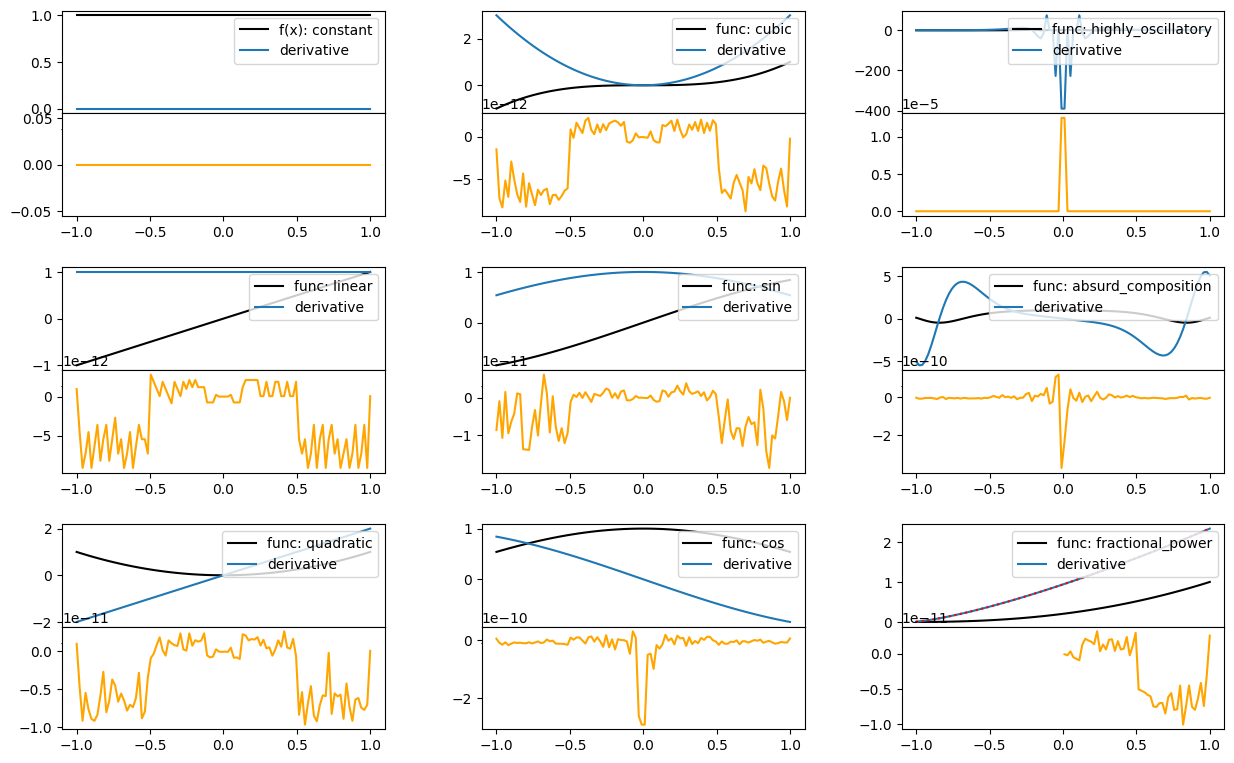

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(15, 10))

# Create a GridSpec with extra height for gaps between groups
gs = gridspec.GridSpec(nrows=9, ncols=3, height_ratios=[1,1, 0.5, 1,1, 0.5, 1,1, 0.5],hspace=0.0, wspace=0.30)

# Column 0 axes
ax00 = fig.add_subplot(gs[0, 0])
ax10 = fig.add_subplot(gs[1, 0], sharex=ax00)

ax20 = fig.add_subplot(gs[3, 0])
ax30 = fig.add_subplot(gs[4, 0], sharex=ax20)

ax40 = fig.add_subplot(gs[6, 0])
ax50 = fig.add_subplot(gs[7, 0], sharex=ax40)

# Column 1 axes
ax01 = fig.add_subplot(gs[0, 1])
ax11 = fig.add_subplot(gs[1, 1], sharex=ax01)

ax21 = fig.add_subplot(gs[3, 1])
ax31 = fig.add_subplot(gs[4, 1], sharex=ax21)

ax41 = fig.add_subplot(gs[6, 1])
ax51 = fig.add_subplot(gs[7, 1], sharex=ax41)

# Column 2 axes
ax02 = fig.add_subplot(gs[0, 2])
ax12 = fig.add_subplot(gs[1, 2], sharex=ax01)

ax22 = fig.add_subplot(gs[3, 2])
ax32 = fig.add_subplot(gs[4, 2], sharex=ax21)

ax42 = fig.add_subplot(gs[6, 2])
ax52 = fig.add_subplot(gs[7, 2], sharex=ax41)

k=0
ax00.plot(x,ys[k],'k',label=f'f(x): {labels[k]}') # constant
ax00.plot(x,yprimes[k],label="derivative")
ax10.plot(x,yprimes[k]-np.zeros(len(x)),color='orange')
ax00.legend(loc='upper right')
k=1
ax20.plot(x,ys[k],'k',label=f'func: {labels[k]}') # linear
ax20.plot(x,yprimes[k],label='derivative')
ax30.plot(x,yprimes[k]/np.ones(len(x))-1,color='orange')
ax20.legend(loc='upper right')
k=2
ax40.plot(x,ys[k],'k',label=f'func: {labels[k]}') # quadratic
ax40.plot(x,yprimes[k],label='derivative')
ax50.plot(x,yprimes[k]/(2*x)-1,color='orange')
ax40.legend(loc='upper right')
k=3
ax01.plot(x,ys[k],'k',label=f'func: {labels[k]}') # cubic
ax01.plot(x,yprimes[k],label='derivative')
ax11.plot(x,yprimes[k]/(3*x**2)-1,color='orange')
ax01.legend(loc='upper right')
k=4
ax21.plot(x,ys[k],'k',label=f'func: {labels[k]}') # sin
ax21.plot(x,yprimes[k],label='derivative')
ax31.plot(x,yprimes[k]/np.cos(x)-1,color='orange')
ax21.legend(loc='upper right')
k=5
ax41.plot(x,ys[k],'k',label=f'func: {labels[k]}') # cos
ax41.plot(x,yprimes[k],label='derivative')
ax51.plot(x,yprimes[k]/-np.sin(x)-1,color='orange')
ax41.legend(loc='upper right')
k=6
ax02.plot(x,ys[k],'k',label=f'func: {labels[k]}') # 
ax02.plot(x,yprimes[k],label='derivative')
def highly_oscillatory_derivative(x):
    x = np.asarray(x)
    result = np.zeros_like(x)
    nonzero_mask = x != 0
    result[nonzero_mask] = -np.cos(1.0 / x[nonzero_mask]) / (x[nonzero_mask] ** 2)
    return result
ax12.plot(x,yprimes[k]/(highly_oscillatory_derivative(x))-1,color='orange')
ax02.legend(loc='upper right')
k=7
ax22.plot(x,ys[k],'k',label=f'func: {labels[k]}') # 
ax22.plot(x,yprimes[k],label='derivative')
ax32.plot(x,yprimes[k]/(-2*x*np.exp(-x**2)*np.cos(5*x**3)-15*x**2*np.exp(-x**2)*np.sin(5*x**3))-1,color='orange')
ax22.legend(loc='upper right')
k=8
ax42.plot(x,ys[k],'k',label=f'func: {labels[k]}') # 
ax42.plot(x,yprimes[k],label='derivative',c='C0')
ax42.plot(x,(7/3)*x**(4/3),c='r',ls=':')
ax52.plot(x,yprimes[k]/((7/3)*x**(4/3))-1,color='orange')
ax42.legend(loc='upper right')
plt.tight_layout()
plt.savefig('test.pdf')

# 2 - Simplified example

In [7]:
step_size=0.01
x = np.array(
    [
        [1,6,11],
        [2,7,12],
        [3,8,13],
        [4,9,14],
        [5,10,15]
    ])
Nz,Nt = x.shape
x = x.T.flatten()
np.savetxt('start_vector.txt',x)
start_vector = 'start_vector.txt'

stencil_obj = Stencil(step_size=step_size,start_vector=start_vector)

In [47]:
print(f'*** Domain ***\nJUST AN ANALOGY: \nn(z) concatenated across all the {Nt} tomographic bins:',x,'\n')
names = ['n(z) with n(z[0]) forward far', 
         'n(z) with n(z[0]) forward near',
         'n(z) with n(z[0]) backward near',
         'n(z) with n(z[0]) backward far']
stencil_points = stencil_obj.five_points_stencil_points(0)
for name,spoint in list(zip(names,stencil_points)):
    print(name+':',spoint)

*** Domain ***
JUST AN ANALOGY: 
n(z) concatenated across all the 3 tomographic bins: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] 

n(z) with n(z[0]) forward far: [ 1.02  2.    3.    4.    5.    6.    7.    8.    9.   10.   11.   12.
 13.   14.   15.  ]
n(z) with n(z[0]) forward near: [ 1.01  2.    3.    4.    5.    6.    7.    8.    9.   10.   11.   12.
 13.   14.   15.  ]
n(z) with n(z[0]) backward near: [ 0.99  2.    3.    4.    5.    6.    7.    8.    9.   10.   11.   12.
 13.   14.   15.  ]
n(z) with n(z[0]) backward far: [ 0.98  2.    3.    4.    5.    6.    7.    8.    9.   10.   11.   12.
 13.   14.   15.  ]


In [48]:
print('*** Image ***\nJUST AN ANALOGY:\nξp(θ;n(z)):',stencil_obj.quadratic(x),'\n')
for name,spoint in list(zip(names,stencil_points)):
    print('ξp(θ;'+name+'):',stencil_obj.quadratic(spoint))

*** Image ***
JUST AN ANALOGY:
ξp(θ;n(z)): [  1   4   9  16  25  36  49  64  81 100 121 144 169 196 225] 

ξp(θ;n(z) with n(z[0]) forward far): [  1.0404   4.       9.      16.      25.      36.      49.      64.
  81.     100.     121.     144.     169.     196.     225.    ]
ξp(θ;n(z) with n(z[0]) forward near): [  1.0201   4.       9.      16.      25.      36.      49.      64.
  81.     100.     121.     144.     169.     196.     225.    ]
ξp(θ;n(z) with n(z[0]) backward near): [  0.9801   4.       9.      16.      25.      36.      49.      64.
  81.     100.     121.     144.     169.     196.     225.    ]
ξp(θ;n(z) with n(z[0]) backward far): [  0.9604   4.       9.      16.      25.      36.      49.      64.
  81.     100.     121.     144.     169.     196.     225.    ]


In [95]:
results = stencil_obj.compute_obs(stencil_obj.quadratic)
j=1
k=0
stencil_name = ['forward far', 'forward near', 'backward near', 'backward far']
for i,res in enumerate(results):
    print(f'i={i}:',f'ξp(θ; n(z{k}) {stencil_name[j-1]}): {res}')
    if j==4:
        print('-'*95)
        j=0
        k+=1
    j+=1

i=0: ξp(θ; n(z0) forward far): [  1.0404   4.       9.      16.      25.      36.      49.      64.
  81.     100.     121.     144.     169.     196.     225.    ]
i=1: ξp(θ; n(z0) forward near): [  1.0201   4.       9.      16.      25.      36.      49.      64.
  81.     100.     121.     144.     169.     196.     225.    ]
i=2: ξp(θ; n(z0) backward near): [  0.9801   4.       9.      16.      25.      36.      49.      64.
  81.     100.     121.     144.     169.     196.     225.    ]
i=3: ξp(θ; n(z0) backward far): [  0.9604   4.       9.      16.      25.      36.      49.      64.
  81.     100.     121.     144.     169.     196.     225.    ]
-----------------------------------------------------------------------------------------------
i=4: ξp(θ; n(z1) forward far): [  1.       4.0804   9.      16.      25.      36.      49.      64.
  81.     100.     121.     144.     169.     196.     225.    ]
i=5: ξp(θ; n(z1) forward near): [  1.       4.0401   9.      16.      25.  

In [100]:
derivatives = stencil_obj.extract_derivatives(results=results)
for i,deriv in enumerate(derivatives):
    print(f'i={i}, deriv={deriv}')

i=0, deriv=[2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
i=1, deriv=[0. 4. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
i=2, deriv=[0. 0. 6. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
i=3, deriv=[0. 0. 0. 8. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
i=4, deriv=[ 0.  0.  0.  0. 10.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
i=5, deriv=[ 0.  0.  0.  0.  0. 12.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
i=6, deriv=[ 0.  0.  0.  0.  0.  0. 14.  0.  0.  0.  0.  0.  0.  0.  0.]
i=7, deriv=[ 0.  0.  0.  0.  0.  0.  0. 16.  0.  0.  0.  0.  0.  0.  0.]
i=8, deriv=[ 0.  0.  0.  0.  0.  0.  0.  0. 18.  0.  0.  0.  0.  0.  0.]
i=9, deriv=[ 0.  0.  0.  0.  0.  0.  0.  0.  0. 20.  0.  0.  0.  0.  0.]
i=10, deriv=[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 22.  0.  0.  0.  0.]
i=11, deriv=[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 24.  0.  0.  0.]
i=12, deriv=[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 26.  0.  0.]
i=13, deriv=[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 28.  0.]
i=14, deriv=[ 0.  0.  0.  0.  0.  

# 3 - Jacobian and Fisher matrices

In [2]:
path = '/gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/fisher_product'

In [3]:
deriv_dv_masked = np.genfromtxt(f'{path}/deriv_dv_masked_0.01.txt')
deriv_ξpm = np.genfromtxt(f'{path}/deriv_ξpm_0.01.txt')
inv_cov = np.genfromtxt(f'{path}/inv_cov.txt')
fisher_matrix = np.genfromtxt(f'{path}/fisher_matrix_0.01.txt')
print(deriv_dv_masked.shape,deriv_ξpm.shape,inv_cov.shape,fisher_matrix.shape)

(414, 2700) (414, 1350) (2700, 2700) (414, 414)


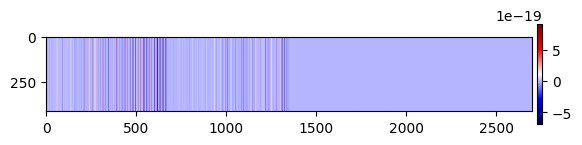

In [27]:
plt.imshow(deriv_dv_masked,cmap='seismic')
plt.colorbar(fraction=0.01, pad=0.01)

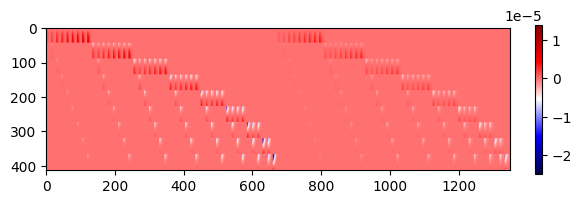

In [32]:
plt.imshow(deriv_ξpm,cmap='seismic')
plt.colorbar(fraction=0.015, pad=0.05)

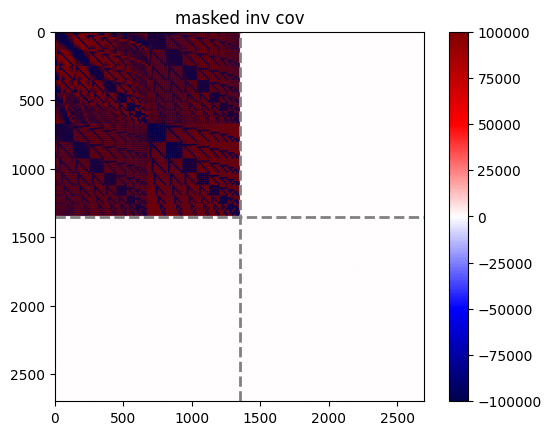

In [33]:
plt.imshow(inv_cov, cmap='seismic', vmin=-1e5, vmax=1e5)
plt.colorbar()
plt.axvline(x=deriv_ξpm.shape[1], color='gray', linestyle='--', linewidth=2)
plt.axhline(y=deriv_ξpm.shape[1], color='gray', linestyle='--', linewidth=2)
plt.title('masked inv cov');

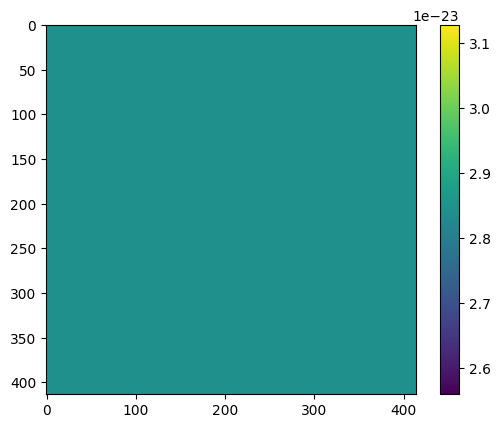

In [34]:
plt.imshow(deriv_dv_masked@inv_cov@deriv_dv_masked.T)
plt.colorbar()

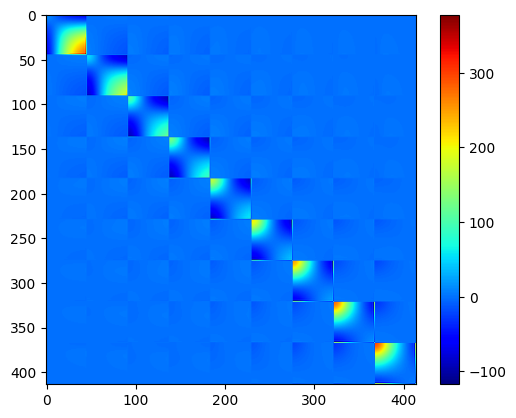

In [44]:
fisher_cut = deriv_ξpm@inv_cov[:deriv_ξpm.shape[1],:deriv_ξpm.shape[1]]@deriv_ξpm.T
plt.imshow(fisher_cut, cmap='jet')
plt.colorbar()

In [42]:
print(np.max(fisher_cut))
print(np.min(fisher_cut))

377.9038127201564
-117.20084296190497
